In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [22]:
df = pd.read_csv(r"../data/orders.csv")
df.head()
TARGET = 'total_amount_usd'

cols_num = [
    'unit_price_usd', 'quantity', 'subtotal_usd', 'discount_pct',
    'discount_amount_usd', 'shipping_fee_usd', 'tax_amount_usd',
    'delivery_days', 'customer_rating',
    'session_duration_minutes', 'pages_viewed_before_purchase'
]

cols_cat = [
    'product_name', 'category', 'payment_method', 'device_used',
    'order_status', 'day_of_week', 'returned', 'is_repeat_customer'
]

In [ ]:
#Contar las categorías, una de las variables más relevantes
df["category"].value_counts()

category
Electronics               4526
Clothing & Apparel        3981
Home & Kitchen            3068
Books                     1962
Sports & Outdoors         1761
Beauty & Personal Care    1710
Toys & Games              1518
Food & Grocery            1472
Health & Wellness         1219
Jewelry & Accessories      973
Office Supplies            770
Automotive                 768
Pet Supplies               751
Travel & Luggage           521
Name: count, dtype: int64

In [24]:
#Usar describe en variables numéricas
print("── Numéricas ──")
display(df[cols_num].describe().round(2))


── Numéricas ──


,unit_price_usd,quantity,subtotal_usd,discount_pct,discount_amount_usd,shipping_fee_usd,tax_amount_usd,delivery_days,customer_rating,session_duration_minutes,pages_viewed_before_purchase
count,25000.00,25000.00,25000.00,25000.00,25000.00,25000.00,25000.00,25000.00,9251.00,25000.00,25000.00
mean,68.12,1.70,116.19,5.63,6.35,3.87,11.75,4.18,4.00,16.78,6.51
std,57.26,1.05,136.99,9.74,17.53,3.27,17.72,2.55,0.58,15.81,5.27
min,3.36,1.00,3.36,0.00,0.00,0.00,0.00,1.00,1.50,0.30,1.00
25%,29.25,1.00,38.47,0.00,0.00,0.00,2.30,3.00,3.60,7.10,2.00
50%,51.53,1.00,72.39,0.00,0.00,3.99,6.22,4.00,4.10,12.10,5.00
75%,87.88,2.00,140.16,10.00,5.25,6.99,13.99,5.00,4.40,21.10,9.00
max,697.03,5.00,2636.45,50.00,421.58,9.99,303.99,14.00,5.00,361.20,24.00


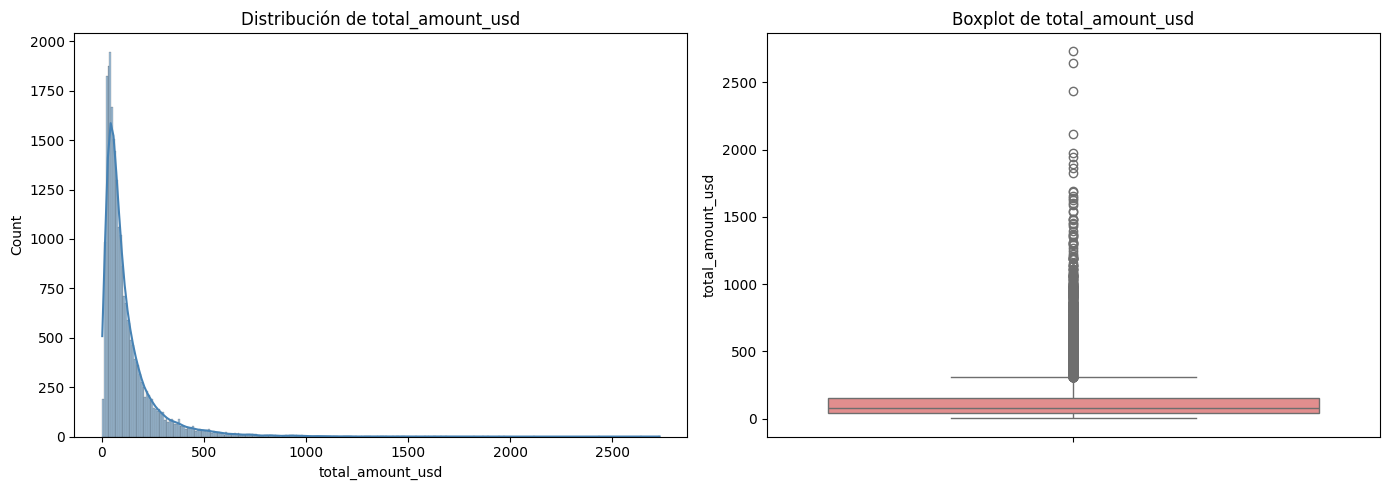

count    25000.00
mean       125.46
std        145.64
min          3.00
25%         43.45
50%         78.78
75%        149.87
max       2730.88
Name: total_amount_usd, dtype: float64


In [ ]:
#Como se distribuye y comporta la variable target
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['total_amount_usd'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribución de total_amount_usd')

sns.boxplot(y=df['total_amount_usd'], ax=axes[1], color='lightcoral')
axes[1].set_title('Boxplot de total_amount_usd')

plt.tight_layout()
plt.show()

print(df['total_amount_usd'].describe().round(2))

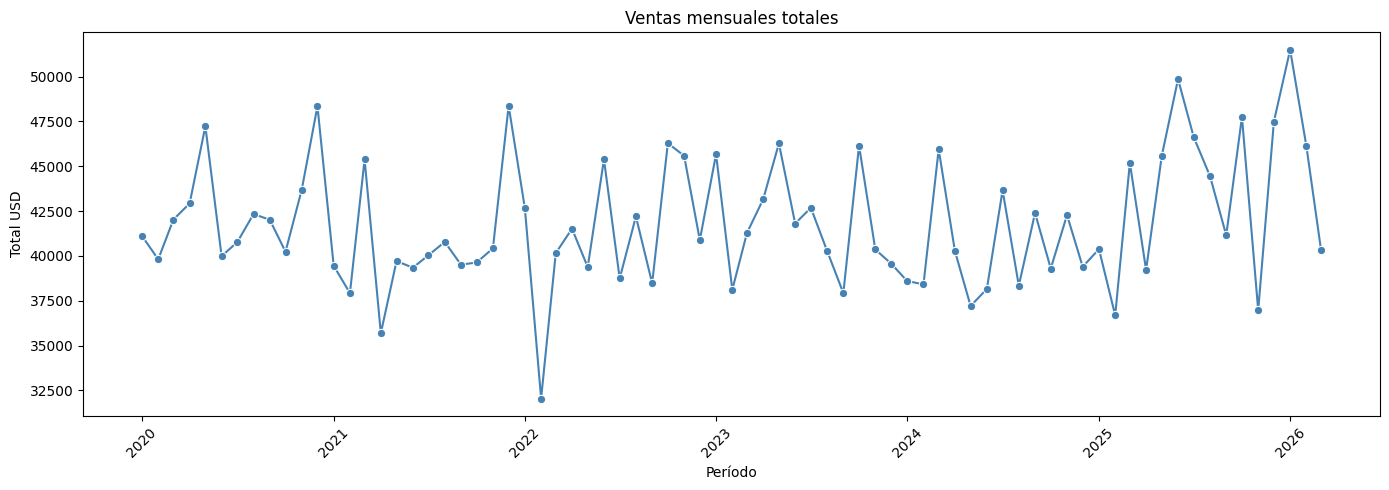

In [ ]:
#Tendencia en el tiempo de la variable target
ventas_mes = (
    df.groupby(['year', 'month'])['total_amount_usd']
    .sum()
    .reset_index()
    .assign(periodo=lambda x: pd.to_datetime(x[['year', 'month']].assign(day=1)))
    .sort_values('periodo')
)

plt.figure(figsize=(14, 5))
sns.lineplot(data=ventas_mes, x='periodo', y='total_amount_usd', marker='o', color='steelblue')
plt.title('Ventas mensuales totales')
plt.xlabel('Período')
plt.ylabel('Total USD')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

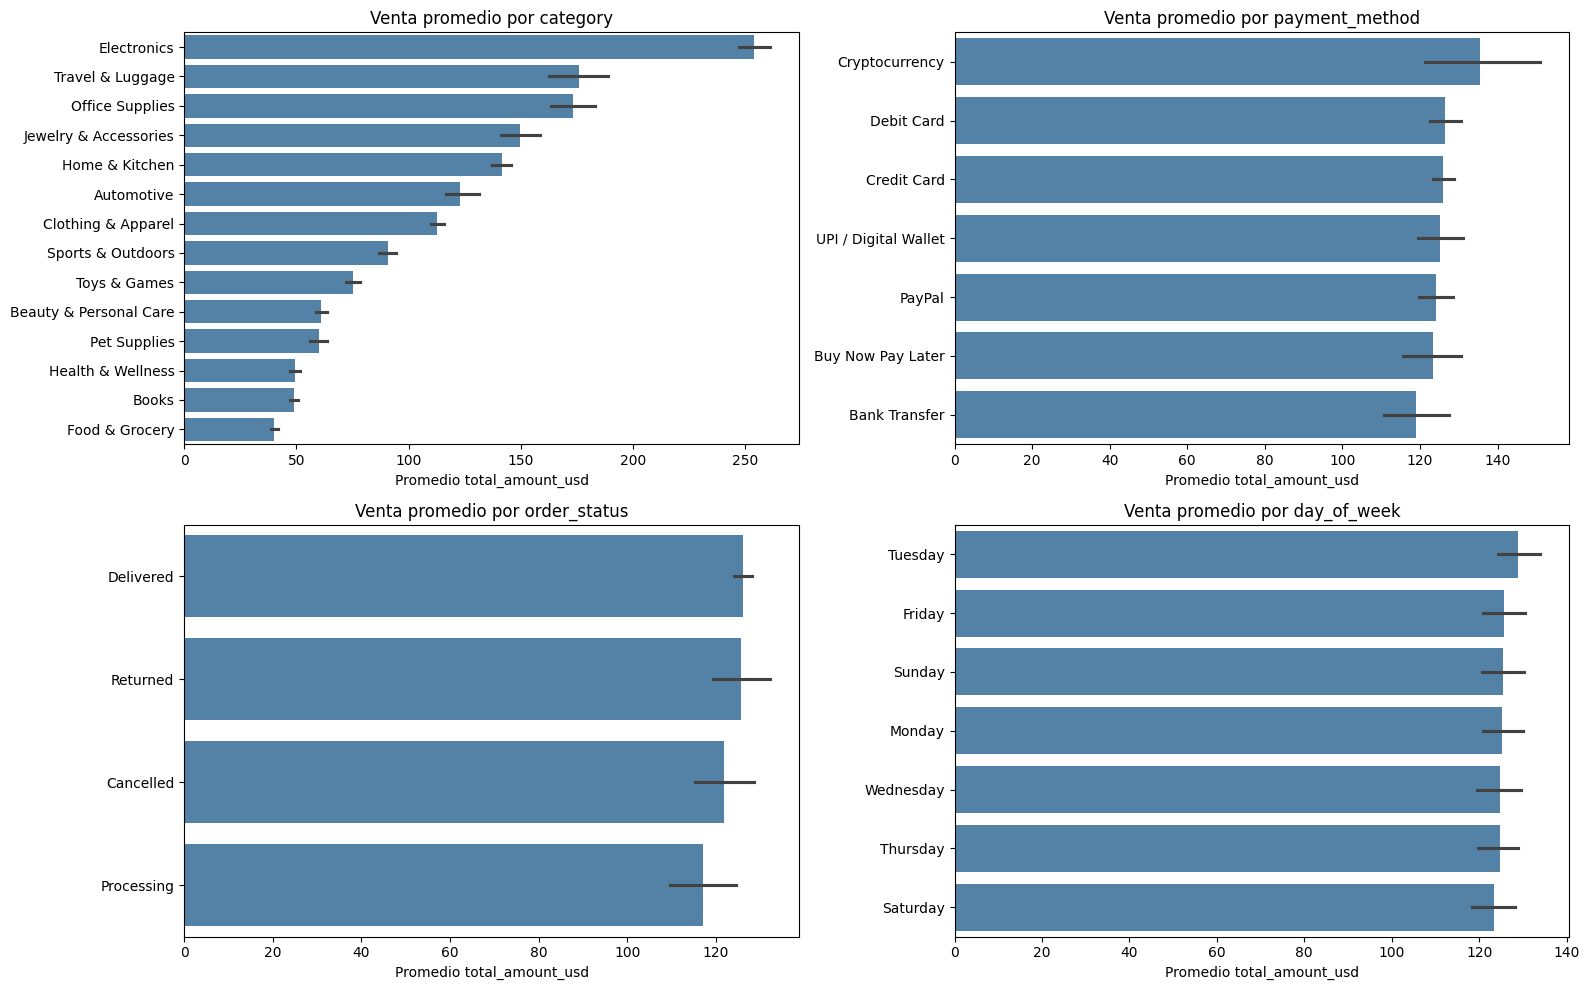

In [ ]:
#Venta promedio por variables categóricas
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(['category', 'payment_method', 'order_status', 'day_of_week']):
    orden = df.groupby(col)[TARGET].mean().sort_values(ascending=False).index
    sns.barplot(data=df, y=col, x=TARGET, order=orden, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Venta promedio por {col}')
    axes[i].set_xlabel('Promedio total_amount_usd')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

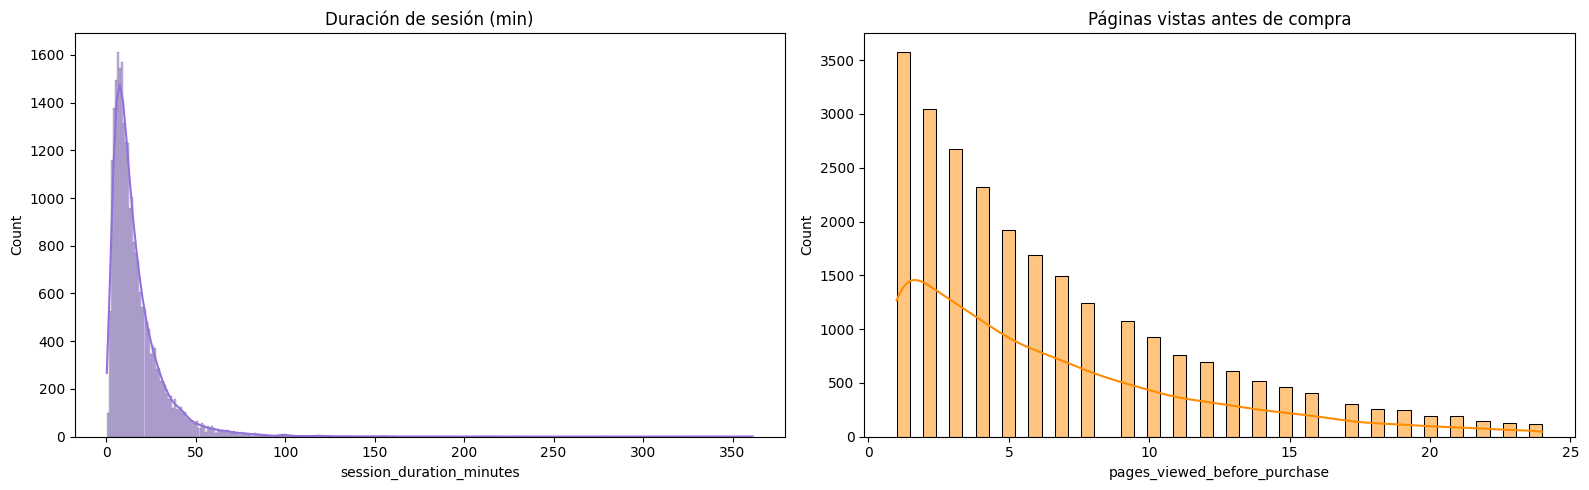

In [ ]:
#Tiempo y páginas antes de comprar
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(df['session_duration_minutes'], kde=True, ax=axes[0], color='mediumpurple')
axes[0].set_title('Duración de sesión (min)')

sns.histplot(df['pages_viewed_before_purchase'], kde=True, ax=axes[1], color='darkorange')
axes[1].set_title('Páginas vistas antes de compra')

plt.tight_layout()
plt.show()

C:\Users\chris\AppData\Local\Temp\ipykernel_22832\4227701649.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='is_repeat_customer', y='total_amount_usd',
C:\Users\chris\AppData\Local\Temp\ipykernel_22832\4227701649.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Nuevo', 'Recurrente'])


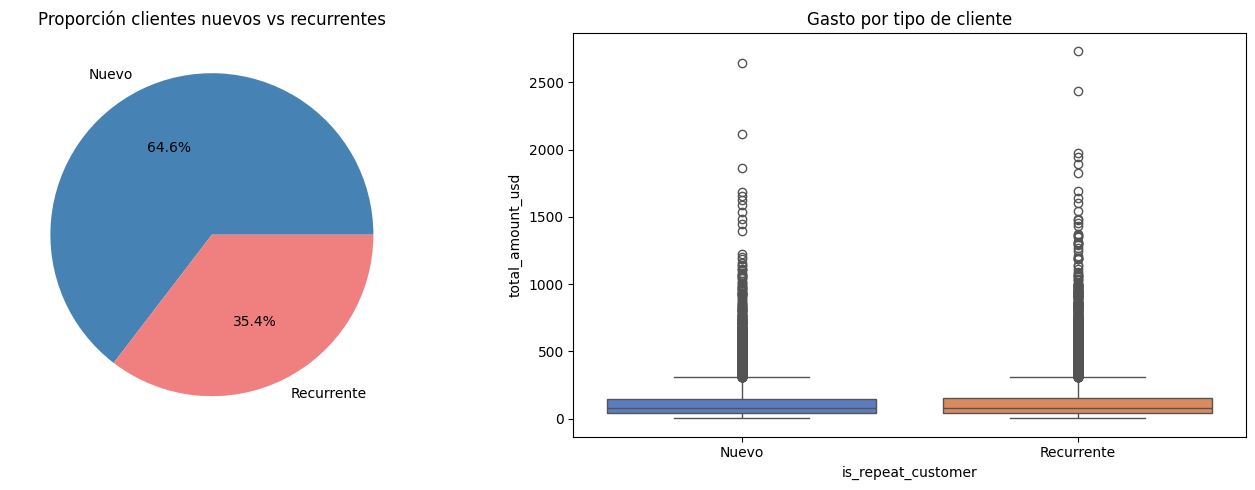

In [ ]:
#Clientes nuevos vs clientes recurrentes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Conteo
df['is_repeat_customer'].value_counts().plot.pie(
    ax=axes[0], autopct='%1.1f%%',
    labels=['Nuevo', 'Recurrente'], colors=['steelblue', 'lightcoral']
)
axes[0].set_title('Proporción clientes nuevos vs recurrentes')
axes[0].set_ylabel('')

# Gasto promedio
sns.boxplot(data=df, x='is_repeat_customer', y='total_amount_usd',
            ax=axes[1], palette='muted')
axes[1].set_title('Gasto por tipo de cliente')
axes[1].set_xticklabels(['Nuevo', 'Recurrente'])

plt.tight_layout()
plt.show()

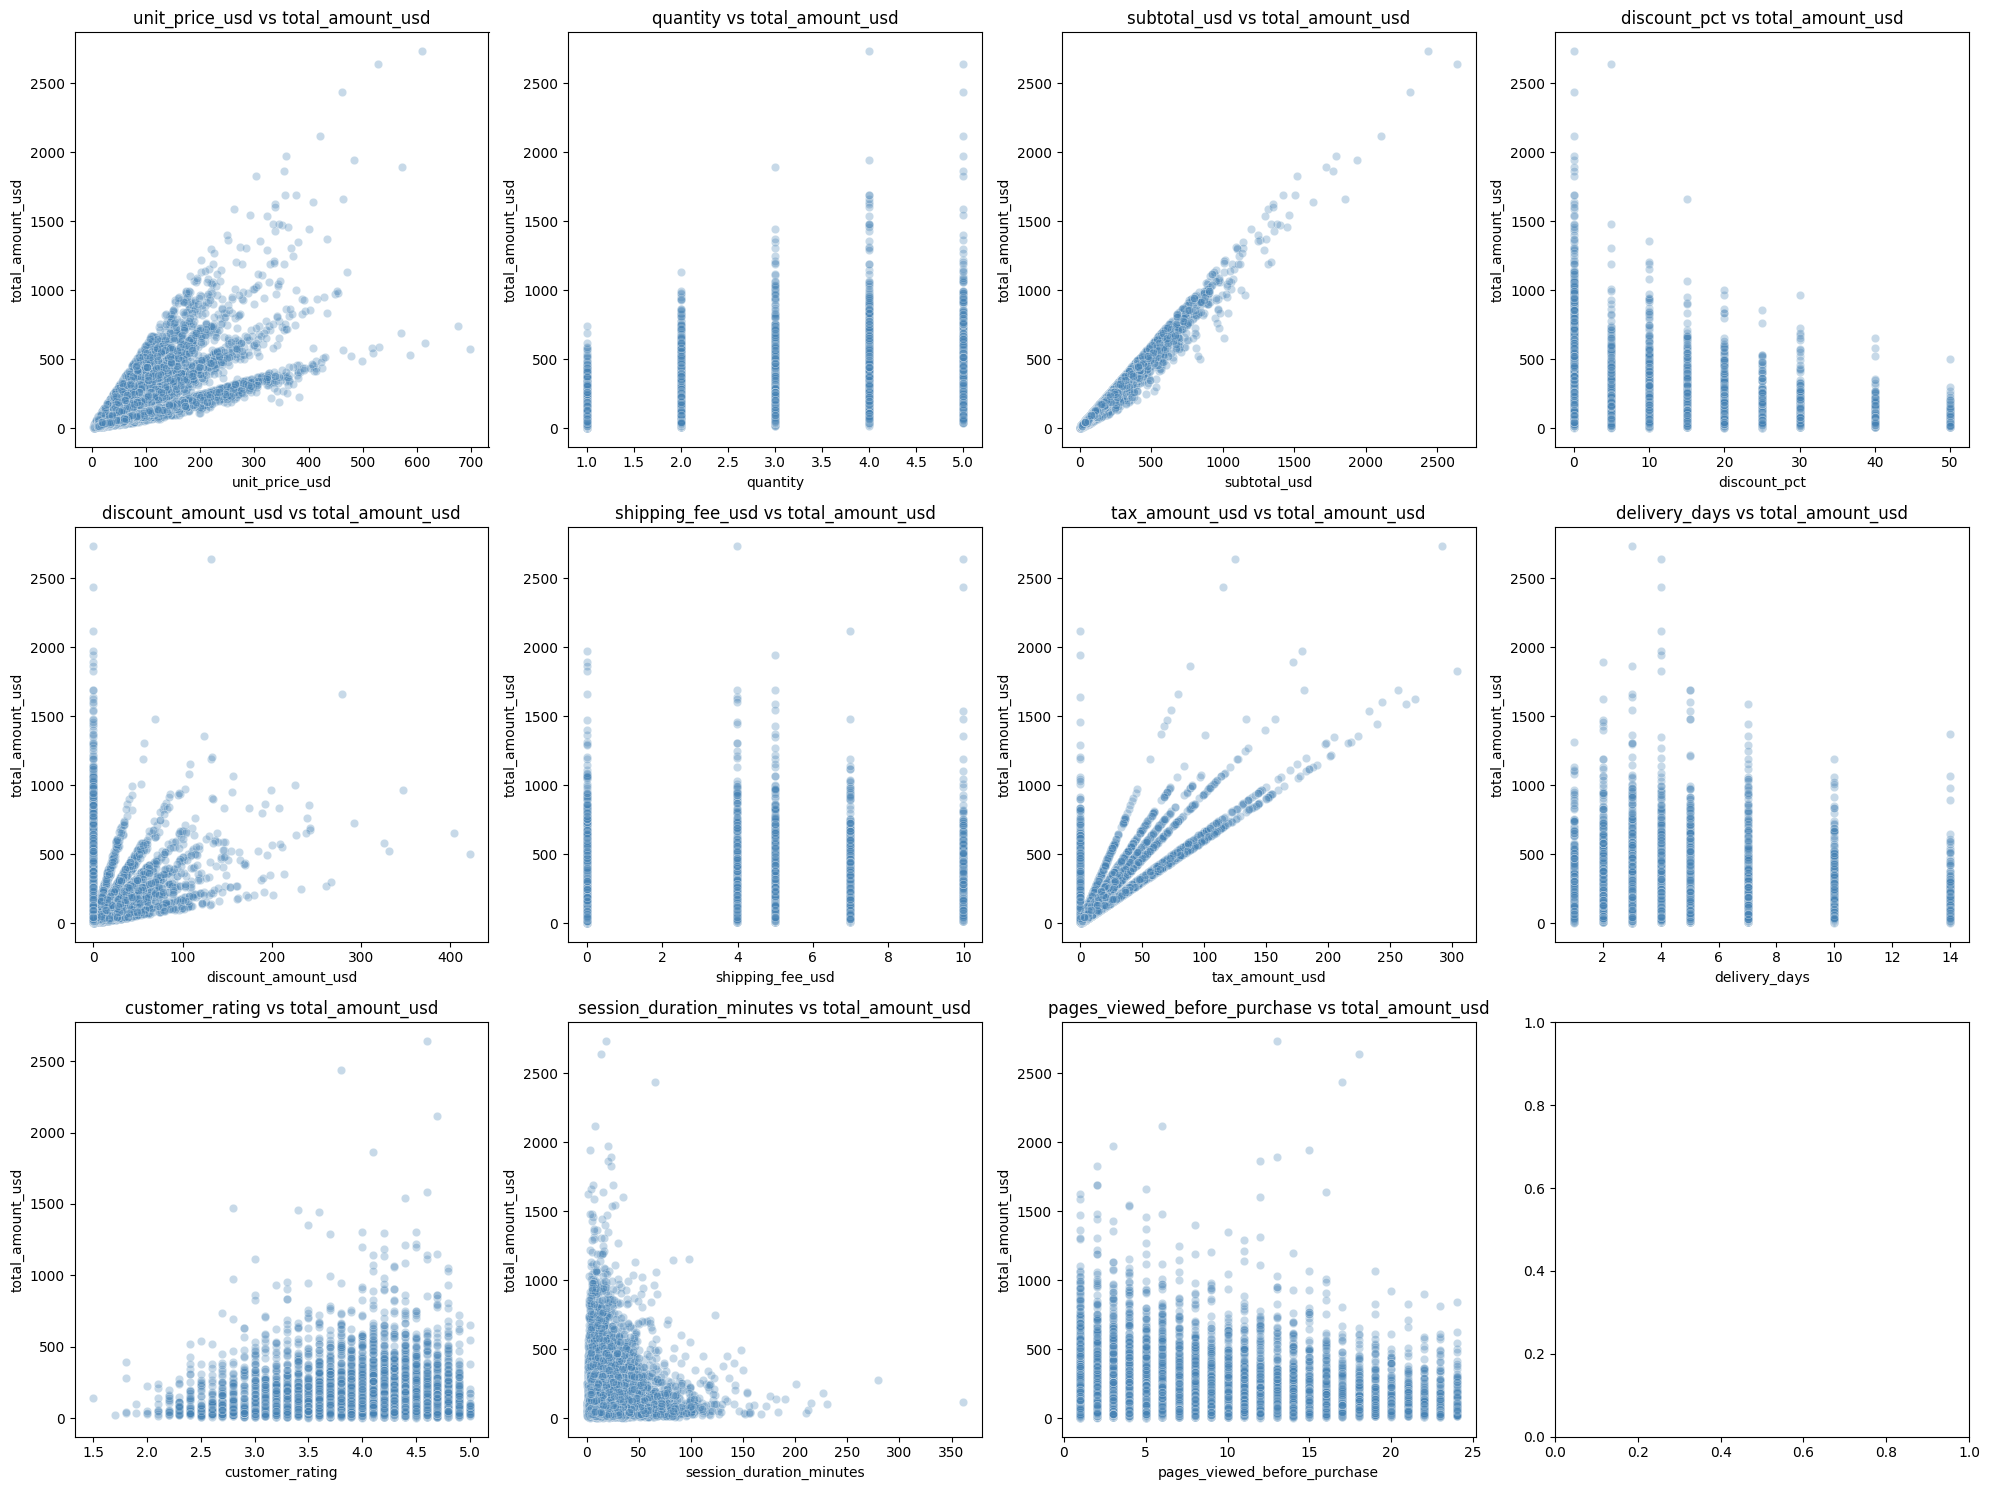

11


In [25]:
#Variable target vs variables númericas
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
axes = axes.flatten()

for i, col in enumerate(cols_num):
    sns.scatterplot(data=df, x=col, y=TARGET, alpha=0.3, ax=axes[i], color='steelblue')
    axes[i].set_title(f'{col} vs {TARGET}')

plt.tight_layout()
plt.show()
print(len(cols_num))

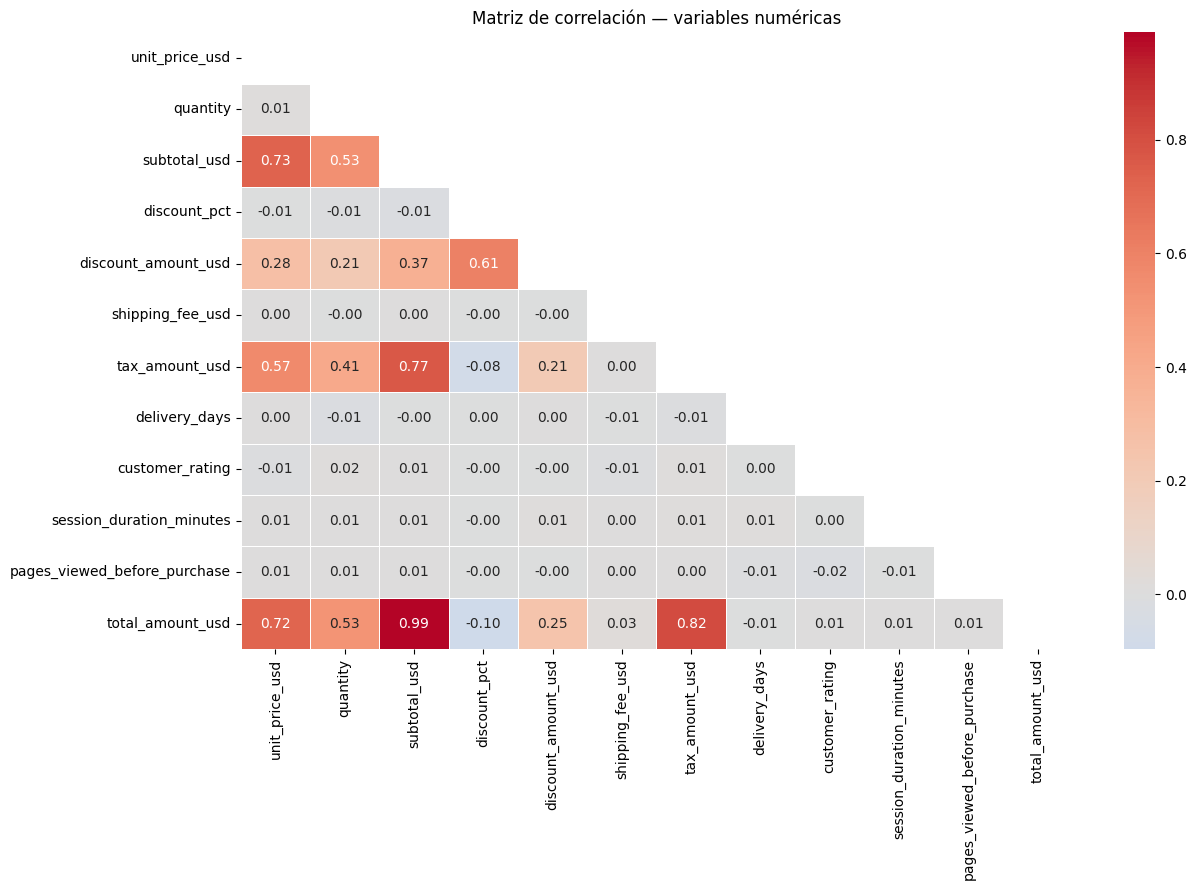

In [26]:
#Matriz de correlación para ver variables númericas relevantees
corr = corr = df[cols_num + [TARGET]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(13, 9))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.5
)
plt.title('Matriz de correlación — variables numéricas')
plt.tight_layout()
plt.show()